In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data into a pandas dataframe

In [3]:
df = pd.read_csv(r"D:\e2eML\telco_churn_azure_ml\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2853,0233-FTHAV,Female,0,No,No,60,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,One year,Yes,Bank transfer (automatic),79.20,4765,No
3483,4465-VDKIQ,Female,0,No,No,18,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,77.80,1358.6,No
1503,0481-SUMCB,Female,1,No,No,45,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),102.15,4735.35,No
5827,3161-GETRM,Male,0,Yes,Yes,34,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),90.05,3097,No
6104,7356-AYNJP,Female,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,23.90,97.5,No
2173,2038-OEQZH,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,No,Electronic check,86.05,308.1,No
113,4846-WHAFZ,Female,1,Yes,No,37,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,76.50,2868.15,Yes
4148,9142-XMYJH,Female,0,No,No,29,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.35,601.6,No
1188,0080-OROZO,Female,0,No,No,35,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,99.25,3532,No
5800,7129-CAKJW,Female,0,No,No,17,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),80.05,1345.65,No


In [10]:
print(f'Summarizing the attributes of the dataframe one by one')
for _ in df.columns:
    unique_values = df[_].nunique()
    print(f'########################################################')
    print(f'Attribute name = {_}')
    print(f'Total number of unqiue value are {unique_values}')
    if unique_values <= 5:
        print(df[_].value_counts())

Summarizing the attributes of the dataframe one by one
########################################################
Attribute name = customerID
Total number of unqiue value are 7043
########################################################
Attribute name = gender
Total number of unqiue value are 2
gender
Male      3555
Female    3488
Name: count, dtype: int64
########################################################
Attribute name = SeniorCitizen
Total number of unqiue value are 2
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
########################################################
Attribute name = Partner
Total number of unqiue value are 2
Partner
No     3641
Yes    3402
Name: count, dtype: int64
########################################################
Attribute name = Dependents
Total number of unqiue value are 2
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
########################################################
Attribute name = tenure
Total number of unqiue 

In [12]:
df[df['Churn'] == 'No'].sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5539,4632-PAOYU,Male,0,Yes,Yes,22,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.95,433.5,No
2420,3694-DELSO,Male,0,Yes,Yes,4,No,No phone service,DSL,Yes,...,No,No,Yes,No,Month-to-month,No,Credit card (automatic),38.55,156.1,No
3282,0330-BGYZE,Male,0,Yes,No,60,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),102.50,6157.6,No
6576,2342-CKIAO,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.30,41.2,No
3435,4450-DLLMH,Male,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),71.30,157.75,No


In [13]:
pd.crosstab(df['SeniorCitizen'], df['Churn'])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [15]:
pd.crosstab(df['MultipleLines'], df['Churn'])

Churn,No,Yes
MultipleLines,,
No,2541,849
No phone service,512,170
Yes,2121,850


In [18]:
df['TotalCharges'].describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

## Performing Statistical tests on the data

In [20]:
from scipy.stats import chi2_contingency

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [61]:
# Separating the numerical and categorical columns
categorical_columns = []
numerical_columns = []
for _ in df.columns:
    if df[_].nunique() < 5:
        categorical_columns.append(_)
    else:
        numerical_columns.append(_)

categorical_columns, numerical_columns

(['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'Churn'],
 ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'])

In [33]:
for i in categorical_columns:
    for j in categorical_columns:
        if i != j:
            # 1. Create a Contingency Table (Cross-tab)
            contingency_table = pd.crosstab(df[i], df[j])

            # 2. Perform Chi-Square Test
            chi2, p, dof, expected = chi2_contingency(contingency_table)

            # 3. Calculate Cramér's V
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape) - 1
            cramers_v = np.sqrt(chi2 / (n * min_dim))
            
            print(f"Statistical Tests between {i} and {j}")
            print(f"Chi-Square: {chi2:.4f}")
            print(f"Cramér's V: {cramers_v:.4f}")
            print(f"P-value: {p:.4f}") # If p < 0.05, they are significantly associated
            print(f"----------------------------------------------------")

Statistical Tests between gender and SeniorCitizen
Chi-Square: 0.0156
Cramér's V: 0.0015
P-value: 0.9006
----------------------------------------------------
Statistical Tests between gender and Partner
Chi-Square: 0.0164
Cramér's V: 0.0015
P-value: 0.8982
----------------------------------------------------
Statistical Tests between gender and Dependents
Chi-Square: 0.7337
Cramér's V: 0.0102
P-value: 0.3917
----------------------------------------------------
Statistical Tests between gender and PhoneService
Chi-Square: 0.2542
Cramér's V: 0.0060
P-value: 0.6141
----------------------------------------------------
Statistical Tests between gender and MultipleLines
Chi-Square: 0.6292
Cramér's V: 0.0095
P-value: 0.7301
----------------------------------------------------
Statistical Tests between gender and InternetService
Chi-Square: 0.9025
Cramér's V: 0.0113
P-value: 0.6368
----------------------------------------------------
Statistical Tests between gender and OnlineSecurity
Chi-Squa

In [34]:
for _ in categorical_columns:
    if _ != 'Churn':
        contingency_table = pd.crosstab(df[_], df['Churn'])
        # 3. Calculate Cramér's V
        n = contingency_table.sum().sum()
        min_dim = min(contingency_table.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim))

        print(f"Statistical Tests between {_} and Churn")
        print(f"Chi-Square: {chi2:.4f}")
        print(f"Cramér's V: {cramers_v:.4f}")
        print(f"P-value: {p:.4f}") # If p < 0.05, they are significantly associated
        print(f"----------------------------------------------------")

Statistical Tests between gender and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between SeniorCitizen and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between Partner and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between Dependents and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between PhoneService and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between MultipleLines and Churn
Chi-Square: 648.1423
Cramér's V: 0.3034
P-value: 0.0000
----------------------------------------------------
Statistical Tests between InternetService and Churn
Chi-Square:

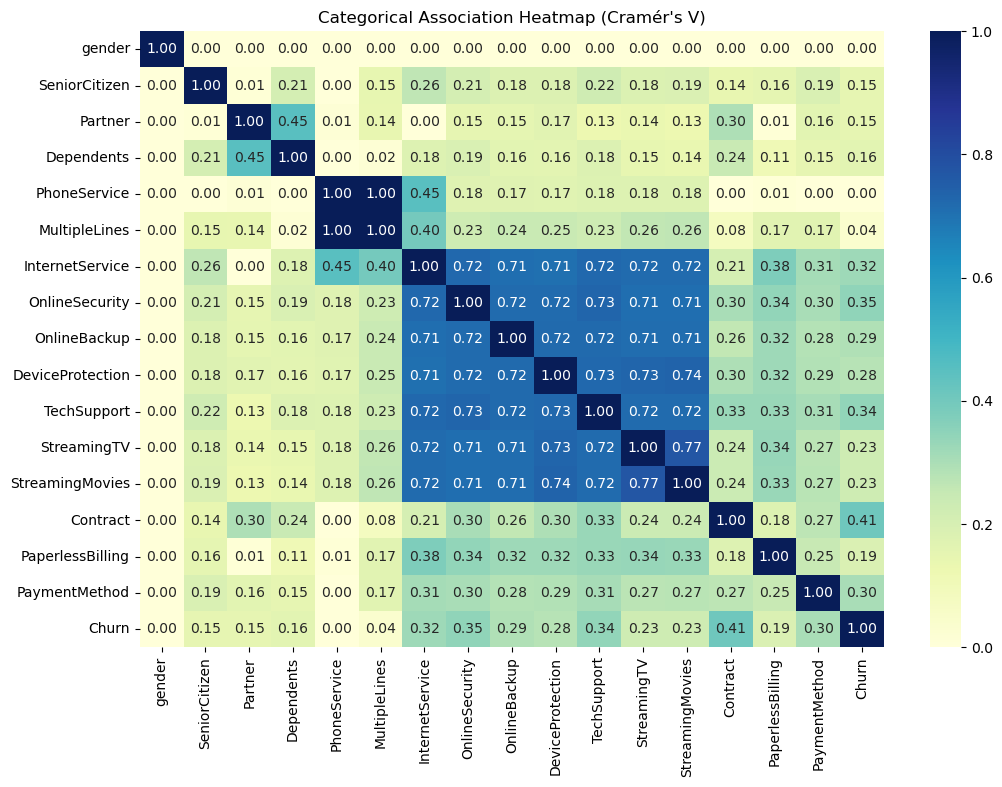

In [35]:
def calculate_cramers_v(df, cols):
    """Calculates Cramer's V matrix for categorical columns."""
    v_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for i in cols:
        for j in cols:
            if i == j:
                v_matrix.loc[i, j] = 1.0
            else:
                confusion_matrix = pd.crosstab(df[i], df[j])
                chi2 = chi2_contingency(confusion_matrix)[0]
                n = confusion_matrix.sum().sum()
                phi2 = chi2 / n
                r, k = confusion_matrix.shape
                # Bias correction for Cramer's V
                phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
                rcorr = r - ((r-1)**2)/(n-1)
                kcorr = k - ((k-1)**2)/(n-1)
                v_matrix.loc[i, j] = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    return v_matrix

# Get the matrix for your categorical columns
cv_matrix = calculate_cramers_v(df, categorical_columns)

# Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cv_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Categorical Association Heatmap (Cramér's V)")
plt.show()

In [62]:
numerical_columns.pop(0)

'customerID'

In [63]:
df[numerical_columns]
# Need to drop TotalCharges as it is tenure * MonthlyCharges
numerical_columns.pop(2)
numerical_columns

['tenure', 'MonthlyCharges']

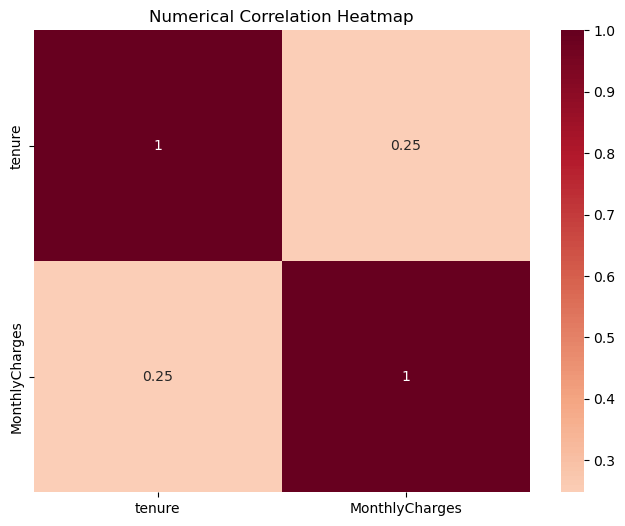

In [54]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title("Numerical Correlation Heatmap")
plt.show()

In [64]:
# need to drop multiple services as phone services and mutliple services have a Cramer's V score of 1
categorical_columns.remove("PhoneService")